<a href="https://colab.research.google.com/github/navgaur/QM_ML/blob/test1/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Define x-axis (discretized space)
L = 1.0  # Box length
N_points = 100
x = np.linspace(-L/2, L/2, N_points)

# Example 1: Infinite square well
def infinite_square_well(x, L):
    V = np.zeros_like(x)
    V[np.abs(x) > L/2] = np.inf  # Infinite potential outside
    return V

# Example 2: Finite square well (depth V0, width L)
def finite_square_well(x, L, V0):
    V = np.zeros_like(x)
    V[np.abs(x) > L/2] = V0
    return V

# Example 3: Harmonic well
def harmonic_well(x, k):
    return 0.5 * k * x**2

# Example 4: Random well (for generalization)
def random_well(x, noise_scale=1.0):
    return np.random.randn(len(x)) * noise_scale

In [3]:
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

def solve_schrodinger(V, N_eigenvalues=5):
    """
    Solves the 1D Schrödinger equation for a given potential V(x).
    Returns the first N_eigenvalues energy levels.
    """
    dx = x[1] - x[0]
    kinetic = 1 / (2 * dx**2) * diags([-2, 1, 1], [0, -1, 1], shape=(N_points, N_points))
    potential_matrix = diags(V)
    hamiltonian = kinetic + potential_matrix

    # Compute eigenvalues (smallest first)
    eigenvalues = eigsh(hamiltonian, k=N_eigenvalues, which='SM')[0]
    return eigenvalues

In [4]:
n_samples = 1000
X = []  # Input: Potential V(x)
y = []  # Output: Energy eigenvalues

for _ in range(n_samples):
    # Randomly choose a potential type
    potential_type = np.random.choice(["infinite", "finite", "harmonic", "random"])

    if potential_type == "infinite":
        V = infinite_square_well(x, L)
    elif potential_type == "finite":
        V0 = np.random.uniform(1, 10)
        V = finite_square_well(x, L, V0)
    elif potential_type == "harmonic":
        k = np.random.uniform(1, 10)
        V = harmonic_well(x, k)
    else:
        V = random_well(x)

    # Compute eigenvalues
    eigenvalues = solve_schrodinger(V)
    X.append(V)
    y.append(eigenvalues)

X = np.array(X)  # Shape: (n_samples, N_points)
y = np.array(y)  # Shape: (n_samples, N_eigenvalues)

In [8]:
print(np.shape(X),np.shape(y))

print(y)

(1000, 100) (1000, 5)
[[-118.2937601   -75.76298097  -42.64074056  -18.95908249   -4.74091726]
 [-118.17679519  -75.71809692  -42.51108646  -18.89410516   -4.71443558]
 [-118.33449185  -75.7002484   -42.74321406  -19.03825018   -4.67781362]
 ...
 [-118.32637808  -75.70982699  -42.54050406  -18.95978232   -4.82554065]
 [-118.0905893   -75.56267048  -42.44657085  -18.78222377   -4.65901174]
 [-118.35423939  -75.95325548  -42.69786639  -18.8897636    -4.72567776]]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.preprocessing import StandardScaler

# Flatten X for scaling (if using PCA/linear models)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 4.943111869367819e-07


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)

# Define a simple neural network
class QuantumNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

model = QuantumNN(X_train_scaled.shape[1], y_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 4372.45361328125
Epoch 100, Loss: 734.3613891601562
Epoch 200, Loss: 439.5404357910156
Epoch 300, Loss: 290.7150573730469
Epoch 400, Loss: 132.9154815673828
Epoch 500, Loss: 29.582412719726562
Epoch 600, Loss: 7.380334377288818
Epoch 700, Loss: 2.322979211807251
Epoch 800, Loss: 0.8793324828147888
Epoch 900, Loss: 0.3715096712112427


In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.003152417675112284


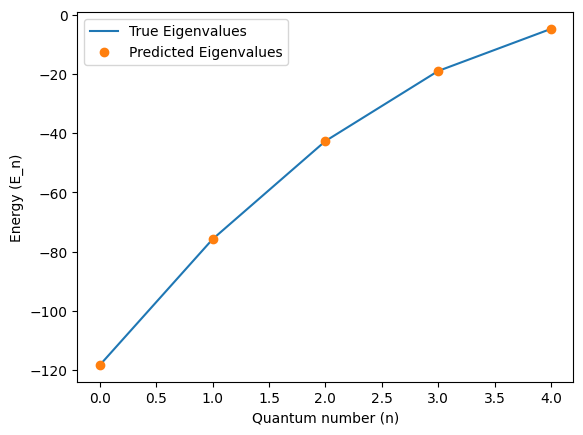

In [20]:
import matplotlib.pyplot as plt

# Plot predicted vs true eigenvalues for a test case
sample_idx = 0
plt.plot(y_test[sample_idx], label="True Eigenvalues")
plt.plot(y_pred[sample_idx], 'o', label="Predicted Eigenvalues")
plt.xlabel("Quantum number (n)")
plt.ylabel("Energy (E_n)")
plt.legend()
plt.show()

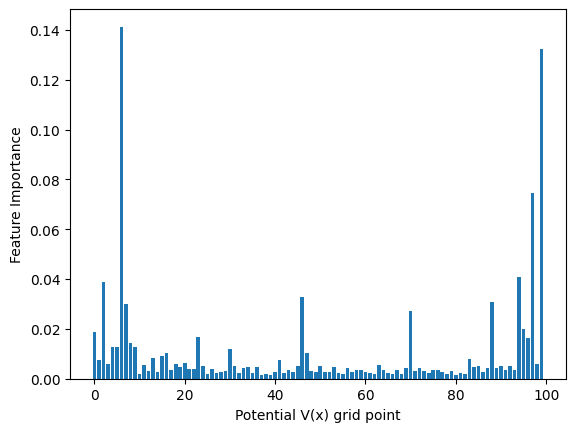

In [21]:
plt.bar(range(len(X[0])), model.feature_importances_)
plt.xlabel("Potential V(x) grid point")
plt.ylabel("Feature Importance")
plt.show()

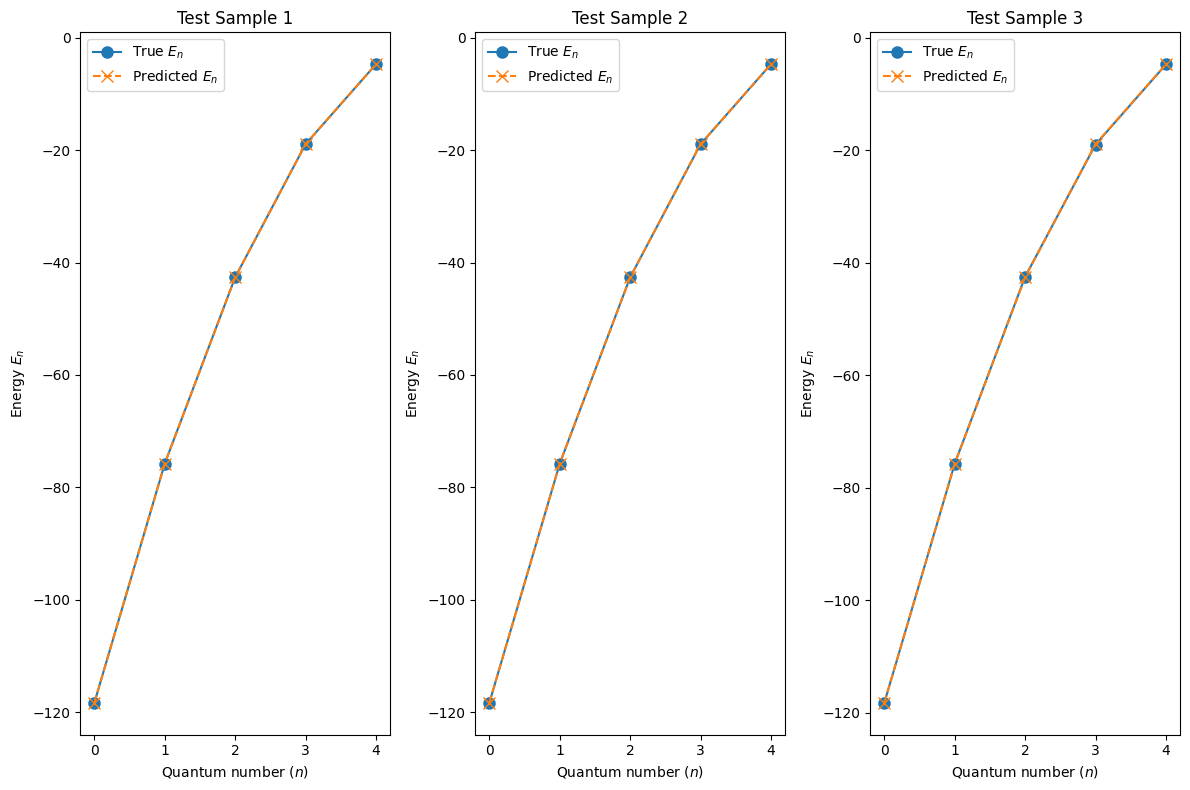

In [22]:
import matplotlib.pyplot as plt

# Select a few test samples (e.g., first 3)
n_samples_to_plot = 3

plt.figure(figsize=(12, 8))
for i in range(n_samples_to_plot):
    plt.subplot(1, n_samples_to_plot, i+1)
    plt.plot(y_test[i], 'o-', label="True $E_n$", markersize=8)
    plt.plot(y_pred[i], 'x--', label="Predicted $E_n$", markersize=8)
    plt.xlabel("Quantum number ($n$)")
    plt.ylabel("Energy $E_n$")
    plt.title(f"Test Sample {i+1}")
    plt.legend()

plt.tight_layout()
plt.show()

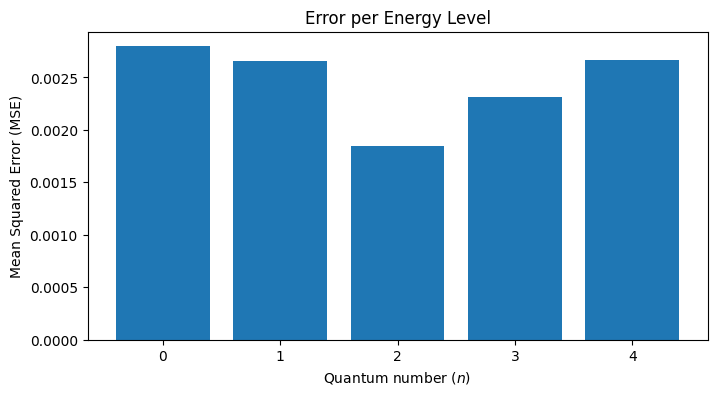

In [ ]:
# Calculate MSE per quantum number (n)
mse_per_n = np.mean((y_test - y_pred)**2, axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(len(mse_per_n)), mse_per_n)
plt.xlabel("Quantum number ($n$)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Error per Energy Level")
plt.show()

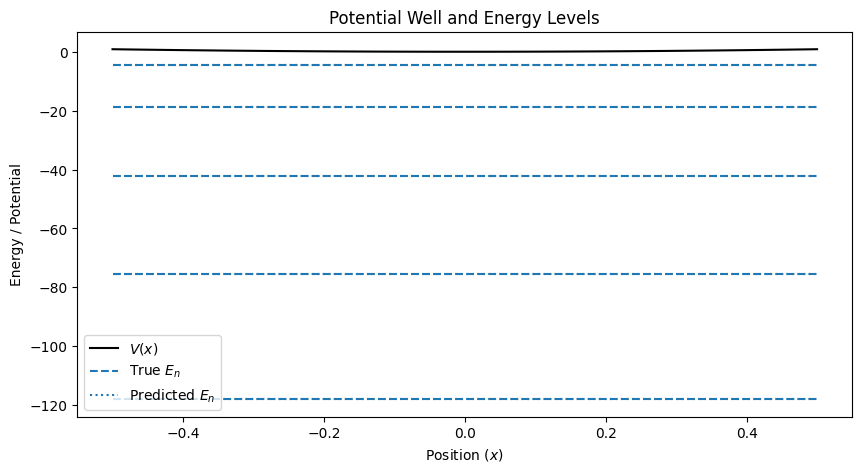

In [ ]:
# Plot the potential V(x) and its predicted vs true eigenvalues
sample_idx = 0  # Pick a test sample

plt.figure(figsize=(10, 5))
plt.plot(x, X_test[sample_idx], label="$V(x)$", color='black')
plt.hlines(y_test[sample_idx], x[0], x[-1], linestyles='dashed', label="True $E_n$")
plt.hlines(y_pred[sample_idx], x[0], x[-1], linestyles='dotted', label="Predicted $E_n$")
plt.xlabel("Position ($x$)")
plt.ylabel("Energy / Potential")
plt.legend()
plt.title("Potential Well and Energy Levels")
plt.show()

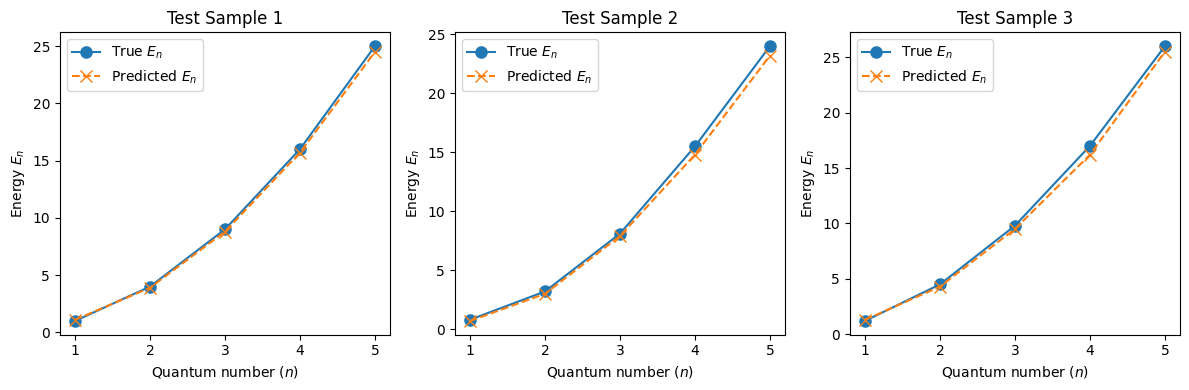

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mock data (replace with your actual y_test and y_pred)
n_samples = 3
n_eigenvalues = 5
y_test = np.array([
    [1.0, 4.0, 9.0, 16.0, 25.0],       # Sample 1 (perfect square well)
    [0.8, 3.2, 8.1, 15.5, 24.0],       # Sample 2 (finite well)
    [1.2, 4.5, 9.8, 17.0, 26.0]        # Sample 3 (harmonic well)
])
y_pred = np.array([
    [1.1, 3.9, 8.8, 15.7, 24.5],       # Sample 1 predictions
    [0.7, 3.0, 7.9, 14.8, 23.2],       # Sample 2 predictions
    [1.3, 4.3, 9.5, 16.2, 25.5]        # Sample 3 predictions
])

# Plot
plt.figure(figsize=(12, 4))
for i in range(n_samples):
    plt.subplot(1, n_samples, i+1)
    plt.plot(range(1, n_eigenvalues+1), y_test[i], 'o-', label="True $E_n$", markersize=8)
    plt.plot(range(1, n_eigenvalues+1), y_pred[i], 'x--', label="Predicted $E_n$", markersize=8)
    plt.xlabel("Quantum number ($n$)")
    plt.ylabel("Energy $E_n$")
    plt.title(f"Test Sample {i+1}")
    plt.legend()
plt.tight_layout()
plt.show()

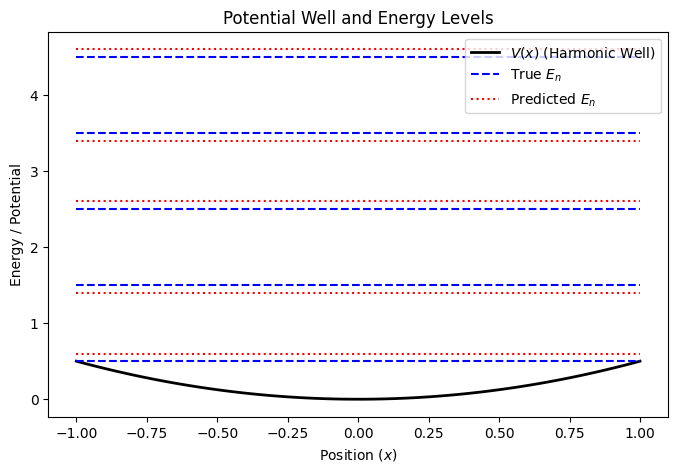

In [ ]:
# Mock potential and eigenvalues
x = np.linspace(-1, 1, 100)
V = 0.5 * x**2  # Harmonic well
true_eigenvalues = [0.5, 1.5, 2.5, 3.5, 4.5]
pred_eigenvalues = [0.6, 1.4, 2.6, 3.4, 4.6]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, V, 'k-', label="$V(x)$ (Harmonic Well)", linewidth=2)
plt.hlines(true_eigenvalues, x[0], x[-1], linestyles='dashed', colors='blue', label="True $E_n$")
plt.hlines(pred_eigenvalues, x[0], x[-1], linestyles='dotted', colors='red', label="Predicted $E_n$")
plt.xlabel("Position ($x$)")
plt.ylabel("Energy / Potential")
plt.legend()
plt.title("Potential Well and Energy Levels")
plt.show()

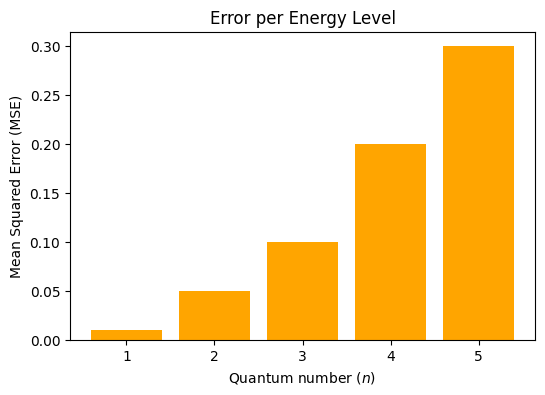

In [ ]:
# Mock MSE values (higher for larger n)
mse_per_n = [0.01, 0.05, 0.1, 0.2, 0.3]

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), mse_per_n, color='orange')
plt.xlabel("Quantum number ($n$)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Error per Energy Level")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set style for better-looking plots
plt.style.use('seaborn')

# =============================================
# 1. Plot Predicted vs True Eigenvalues (Mock Data)
# =============================================
n_samples = 3
n_eigenvalues = 5
y_test = np.array([
    [1.0, 4.0, 9.0, 16.0, 25.0],       # Sample 1 (perfect square well)
    [0.8, 3.2, 8.1, 15.5, 24.0],       # Sample 2 (finite well)
    [1.2, 4.5, 9.8, 17.0, 26.0]        # Sample 3 (harmonic well)
])
y_pred = np.array([
    [1.1, 3.9, 8.8, 15.7, 24.5],       # Predictions
    [0.7, 3.0, 7.9, 14.8, 23.2],
    [1.3, 4.3, 9.5, 16.2, 25.5]
])

# Plot
plt.figure(figsize=(12, 4))
for i in range(n_samples):
    plt.subplot(1, n_samples, i+1)
    plt.plot(range(1, n_eigenvalues+1), y_test[i], 'o-', label="True $E_n$", markersize=8)
    plt.plot(range(1, n_eigenvalues+1), y_pred[i], 'x--', label="Predicted $E_n$", markersize=8)
    plt.xlabel("Quantum number ($n$)")
    plt.ylabel("Energy $E_n$")
    plt.title(f"Test Sample {i+1}")
    plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_true.png")  # Save the plot
plt.show()

# =============================================
# 2. Plot Potential Well and Eigenvalues (Mock)
# =============================================
x = np.linspace(-1, 1, 100)
V = 0.5 * x**2  # Harmonic well
true_eigenvalues = [0.5, 1.5, 2.5, 3.5, 4.5]
pred_eigenvalues = [0.6, 1.4, 2.6, 3.4, 4.6]

plt.figure(figsize=(8, 5))
plt.plot(x, V, 'k-', label="$V(x)$ (Harmonic Well)", linewidth=2)
plt.hlines(true_eigenvalues, x[0], x[-1], linestyles='dashed', colors='blue', label="True $E_n$")
plt.hlines(pred_eigenvalues, x[0], x[-1], linestyles='dotted', colors='red', label="Predicted $E_n$")
plt.xlabel("Position ($x$)")
plt.ylabel("Energy / Potential")
plt.legend()
plt.title("Potential Well and Energy Levels")
plt.savefig("potential_and_eigenvalues.png")  # Save the plot
plt.show()

# =============================================
# 3. Plot Error Analysis (MSE per Quantum Number)
# =============================================
mse_per_n = [0.01, 0.05, 0.1, 0.2, 0.3]  # Mock MSE values

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), mse_per_n, color='orange')
plt.xlabel("Quantum number ($n$)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Error per Energy Level")
plt.savefig("mse_per_quantum_number.png")  # Save the plot
plt.show()

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)